### Limpieza de datos: ejemplo aplicado

In [1]:
# Importamos las librerías necesarias
import numpy as np
import pandas as pd

# Cargamos la base de datos
data = pd.read_csv("clientes_retailplus(1).csv")
# Obtenemos al información general de la base de datos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         3000 non-null   int64  
 1   Age                 2922 non-null   float64
 2   Gender              2940 non-null   object 
 3   Income              2882 non-null   float64
 4   City_Type           3000 non-null   object 
 5   Online_Purchases    3000 non-null   int64  
 6   Store_Purchases     3000 non-null   int64  
 7   Avg_Ticket          3000 non-null   float64
 8   Total_Spending      3000 non-null   float64
 9   Membership_Years    3000 non-null   float64
 10  Returns_Rate        2931 non-null   float64
 11  Satisfaction_Score  2850 non-null   float64
dtypes: float64(7), int64(3), object(2)
memory usage: 281.4+ KB


In [2]:
data.head()

,Customer_ID,Age,Gender,Income,City_Type,Online_Purchases,Store_Purchases,Avg_Ticket,Total_Spending,Membership_Years,Returns_Rate,Satisfaction_Score
0,1,43.960570,Male,6686.505070,Suburban,4,12,154.834821,5201.895347,5.342243,13.155568,4.0
1,2,36.340828,Female,31970.709425,Urban,5,12,938.178711,13415.760582,0.286810,3.528137,5.0
2,3,45.772262,Female,23554.760137,Urban,6,6,414.321153,8823.857031,2.888162,42.418739,6.0
3,4,56.276358,Male,27287.145933,Suburban,6,5,1042.640987,13190.357191,4.654160,15.008286,6.0
4,5,35.190160,Male,15433.085654,Urban,9,5,1214.310483,17011.338910,0.600817,9.621857,7.0


### Sección 1. Exploración y detección de problemas
- Objetivo: identificar variables clave para el negocio y detectar missing, outliers y sesgos.

In [3]:
data.describe().round(0)

,Customer_ID,Age,Income,Online_Purchases,Store_Purchases,Avg_Ticket,Total_Spending,Membership_Years,Returns_Rate,Satisfaction_Score
count,3000.0,2922.0,2882.0,3000.0,3000.0,3000.0,3000.0,3000.0,2931.0,2850.0
mean,1500.0,39.0,25914.0,6.0,8.0,1031.0,14819.0,2.0,18.0,6.0
std,866.0,13.0,21455.0,2.0,4.0,1012.0,16857.0,2.0,16.0,2.0
min,1.0,-1.0,3235.0,1.0,1.0,17.0,-3085.0,0.0,0.0,4.0
25%,751.0,30.0,15390.0,4.0,6.0,477.0,6294.0,1.0,9.0,5.0
50%,1500.0,38.0,21729.0,6.0,8.0,810.0,11153.0,1.0,15.0,6.0
75%,2250.0,46.0,31462.0,7.0,10.0,1295.0,18584.0,3.0,23.0,8.0
max,3000.0,102.0,491523.0,16.0,50.0,18966.0,298392.0,16.0,150.0,9.0


#### 1.	Calcula el porcentaje de valores faltantes por variable.
- ¿Cuáles son las variables con missing values?

In [4]:
# Calculamos el porcentaje de valores faltantes en cada columna
missing_percent = data.isnull().mean() * 100
print("\nPorcentaje de valores faltantes por columna:")
print(missing_percent.round(2).sort_values(ascending=False))


Porcentaje de valores faltantes por columna:
Satisfaction_Score    5.00
Income                3.93
Age                   2.60
Returns_Rate          2.30
Gender                2.00
Customer_ID           0.00
City_Type             0.00
Online_Purchases      0.00
Avg_Ticket            0.00
Store_Purchases       0.00
Membership_Years      0.00
Total_Spending        0.00
dtype: float64


#### 	2.	En la variable Age, identifica:
- Valores fuera de un rango razonable para clientes (por ejemplo, <18 o >90).
- ¿Cuántos casos representan?

In [5]:
# Valores fuera del rango de clientes en la variable Age entre 18 y 90 años
age_outliers = data[(data['Age'] < 18) | (data['Age'] > 90)]
print("Número de outliers en Age:", len(age_outliers))

Número de outliers en Age: 160


In [6]:
# ¿Qué porcentaje de clientes representa age_outliers?
age_outliers_percentage = len(age_outliers) / len(data) * 100
print(f"Porcentaje de clientes con Age fuera del rango: {age_outliers_percentage:.2f}%")


Porcentaje de clientes con Age fuera del rango: 5.33%


#### 3. Elimina o corrige los valores fuera del rango de edad razonable.
- ¿Cuántas observaciones quedán en la base de datos?

In [7]:
# Eliminamos los outliers de la variable Age
data_cleaned = data[(data['Age'] >= 18) & (data['Age'] <= 90)]
print("Número de clientes después de eliminar outliers en Age:", len(data_cleaned))

Número de clientes después de eliminar outliers en Age: 2762


#### 4. Corríge los missing values de la variable Age, imputando en los valores faltantes el promedio de las observaciones, después de quitar a los clientes fuera del rango de edad de interés, ¿cuál es el promedio de la variable? Nota: Redondea a cero decimales

In [8]:
# Calculamos el promedio de Age y luego imputamos el valor en los missing values de la variables
age_median = data_cleaned['Age'].median()
data_cleaned['Age'].fillna(age_median, inplace=True)
#^ llena las variables sin valores con el promedio
print("Número de valores faltantes en Age después de imputación con mediana:", data['Age'].isnull().sum())
print(age_median.round(0))

Número de valores faltantes en Age después de imputación con mediana: 78
39.0


/tmp/ipykernel_46309/3113109170.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_cleaned['Age'].fillna(age_median, inplace=True)
/tmp/ipykernel_46309/3113109170.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['Age'].fillna(age_median, inplace=True)


In [9]:
# Conteo de valores en la variable Age después de imputar con mediana 
data_cleaned['Age'].count()


np.int64(2762)

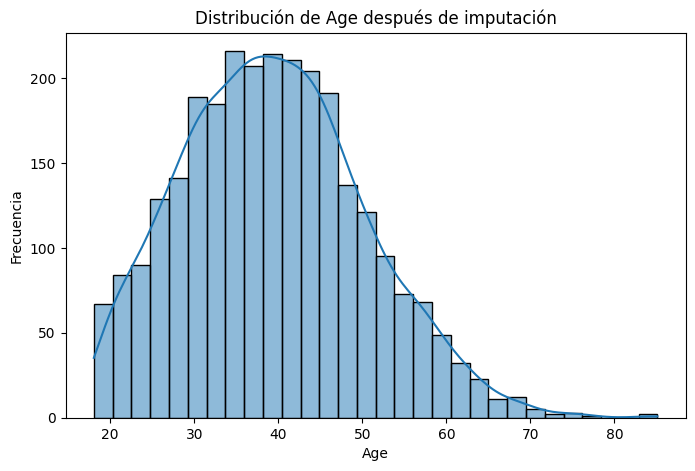

In [10]:
# Histograma de la variable Age después de la imputación
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(data_cleaned['Age'], bins=30, kde=True)
plt.title('Distribución de Age después de imputación')
plt.xlabel('Age')
plt.ylabel('Frecuencia')
plt.show()

#### 5.	Analiza la variable Income, realiza un histograma y calcúla su coeficiente de asimetría.
- ¿Presenta asimetría?
- ¿Hacia qué lado está sesgada?


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


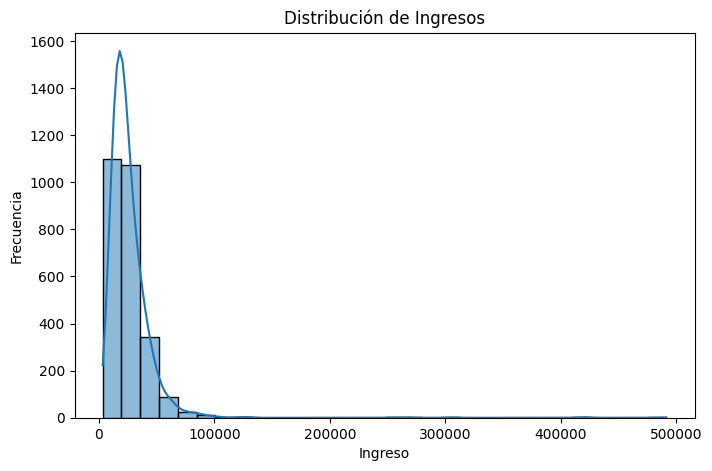

Coeficiente de asimetría de Income: 10.13


In [11]:
# Analizamos la asimetria de la variable Income, primero con un histograma y luego con el coeficiente de asimetria
! pip install scipy
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
plt.figure(figsize=(8, 5))
sns.histplot(data_cleaned['Income'], bins=30, kde=True)
plt.title('Distribución de Ingresos')
plt.xlabel('Ingreso')
plt.ylabel('Frecuencia')
plt.show()
income_skewness = skew(data['Income'].dropna())
print(f"Coeficiente de asimetría de Income: {income_skewness:.2f}")


In [12]:
#Contamos los valores de la varible Income que superen los 100,000 dólares
high_income_count=data_cleaned[data_cleaned['Income']>100000].shape[0]
print(high_income_count)

11


In [13]:
# Borramos los valores atípicos en la variable Income, considerando como umbral los 100,000 dólares

data_cleaned=data_cleaned[data_cleaned['Income']<=100000]
print(len(data_cleaned))

2643


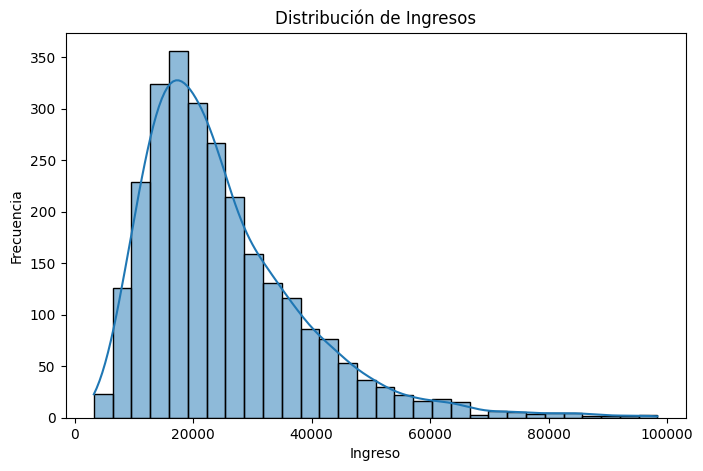

Coeficiente de asimetría de Income: 10.13


In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(data_cleaned['Income'], bins=30, kde=True)
plt.title('Distribución de Ingresos')
plt.xlabel('Ingreso')
plt.ylabel('Frecuencia')
plt.show()
income_skewness = skew(data['Income'].dropna())
print(f"Coeficiente de asimetría de Income: {income_skewness:.2f}")


#### 6. ¿Cuál sería la mejor estrategía de imputación más recomendada para la variable Income?
- Media
- Mediana
- Moda
- Eliminación

#### 7. Aplica la técnica que seleccionaste en la pregunta anterior para corregír el problema de missing values de la variable Income

In [15]:
# Imputación Income con mediana
print("\nRespuesta: imputación Income con MEDIANA (robusta a sesgo/outliers)")
data_clean = data_cleaned.copy()
income_median = data_clean["Income"].median(skipna=True)
print("Mediana Income =", income_median.round(2))
data_clean["Income"] = data_clean["Income"].fillna(income_median)



Respuesta: imputación Income con MEDIANA (robusta a sesgo/outliers)
Mediana Income = 21780.75


In [16]:
# Asimetria de Income después de la imputación 
income_skewness_after = skew(data_clean['Income'].dropna())
print(f"Coeficiente de asimetría de Income después de imputación: {income_skewness_after:.2f}")

Coeficiente de asimetría de Income después de imputación: 1.55


#### 8. Analiza las variables Online_Purchases y Store_Purchases
- Compara sus estadísticas descriptivas o sus distribuciones (con histograma)
- ¿Existe algún tipo de problema con las variables? ¿Cuál?
    - Sesgo de los datos
    - Sesgo de la variable
    - Outliers


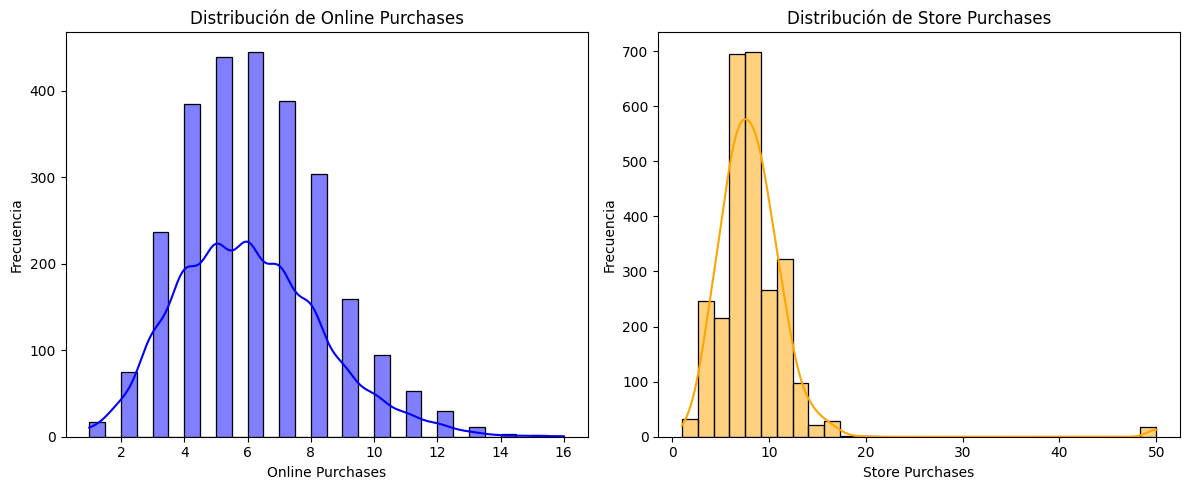

In [17]:
# Comparamos las distribuciones de las variables Online_Purchases y Store_Purchases 
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data_clean['Online_Purchases'], bins=30, kde=True, color='blue')
plt.title('Distribución de Online Purchases')
plt.xlabel('Online Purchases')
plt.ylabel('Frecuencia')
plt.subplot(1, 2, 2)
sns.histplot(data_clean['Store_Purchases'], bins=30, kde=True, color='orange')
plt.title('Distribución de Store Purchases')
plt.xlabel('Store Purchases')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

In [18]:
# Identificamos outliers en Store_Purchases usando el método del rango intercuartílico (IQR)
Q1 = data_clean['Store_Purchases'].quantile(0.25)
Q3 = data_clean['Store_Purchases'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
store_outliers = data_clean[(data_clean['Store_Purchases'] < lower_bound) | (data_clean['Store_Purchases'] > upper_bound)]
print("Número de outliers en Store_Purchases:", len(store_outliers))

Número de outliers en Store_Purchases: 30


In [19]:
# Eliminamos los outliers de Store_Purchases
data_cleaned = data_cleaned[(data_cleaned['Store_Purchases'] >= lower_bound) & (data_cleaned['Store_Purchases'] <= upper_bound)]
print("Número de clientes después de eliminar outliers en Store_Purchases:", len(data_cleaned))

Número de clientes después de eliminar outliers en Store_Purchases: 2613


#### 8. Analizamos la variable Avg_Ticket
- Grafica su histograma

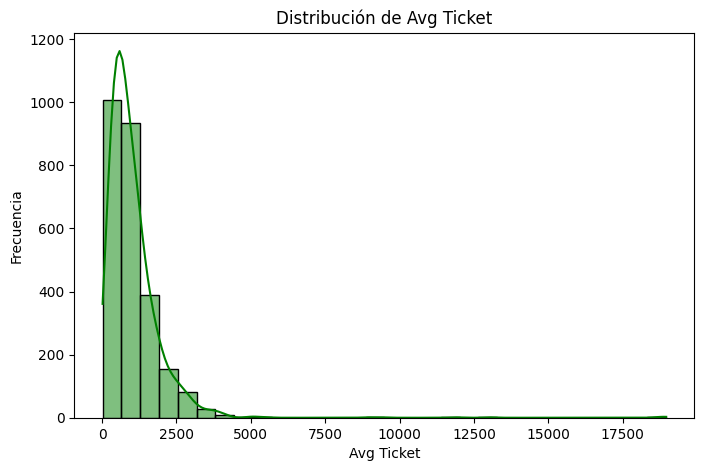

In [20]:
# Grficamos el histograma de la variable Avg_Ticket
plt.figure(figsize=(8, 5))
sns.histplot(data_cleaned['Avg_Ticket'], bins=30, kde=True, color='green')
plt.title('Distribución de Avg Ticket')
plt.xlabel('Avg Ticket')
plt.ylabel('Frecuencia')
plt.show()

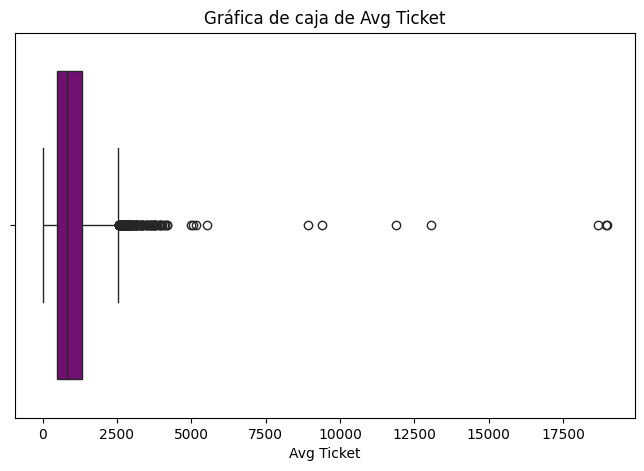

In [21]:
# Grsfica de caja del Avg_Ticket
plt.figure(figsize=(8, 5))
sns.boxplot(x=data_cleaned['Avg_Ticket'], color='purple')
plt.title('Gráfica de caja de Avg Ticket')
plt.xlabel('Avg Ticket')
plt.show()

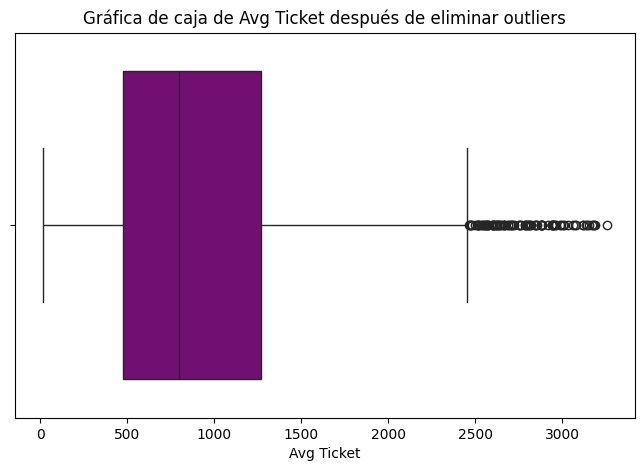

In [22]:
# Eliminamos los outliers de Avg_Ticket usando el método del rango intercuartílico (IQR)
Q3 = data_cleaned['Avg_Ticket'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
data_cleaned = data_cleaned[(data_cleaned['Avg_Ticket'] >= lower_bound) & (data_cleaned['Avg_Ticket'] <= upper_bound)]
# Grafico para  Avg_Ticket después de eliminar outliers con boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=data_cleaned['Avg_Ticket'], color='purple')
plt.title('Gráfica de caja de Avg Ticket después de eliminar outliers')
plt.xlabel('Avg Ticket')
plt.show() 


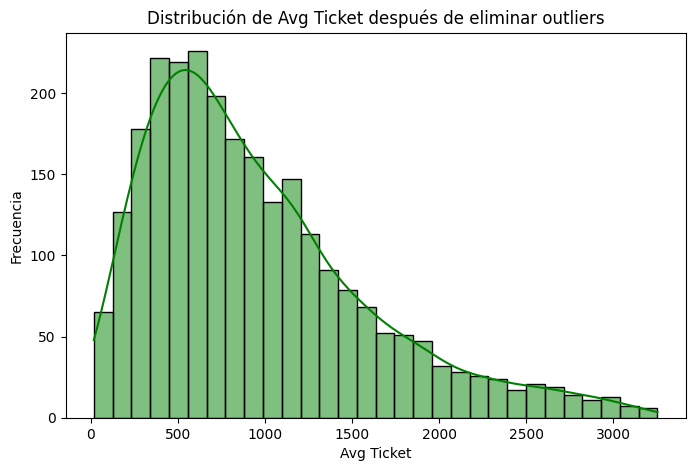

In [23]:
# Grafico para  Avg_Ticket después de eliminar outliers
plt.figure(figsize=(8, 5))
sns.histplot(data_cleaned['Avg_Ticket'], bins=30, kde=True, color='green')
plt.title('Distribución de Avg Ticket después de eliminar outliers')
plt.xlabel('Avg Ticket')
plt.ylabel('Frecuencia')
plt.show()

#### 9. Vamos a analizar la variable Total_Spending
- Estadistica desriptiva
- Grafica un histograma o boxplot
- ¿Por qué podrían ser un poblema? ¿Qué técnica aplicarias para solucionar los outliers de la variable?


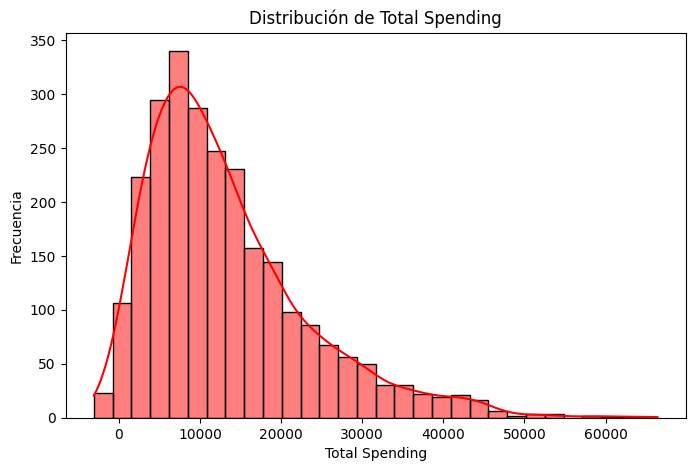

In [24]:
# Histograma de la variable Total_Spending
plt.figure(figsize=(8, 5))
sns.histplot(data_cleaned['Total_Spending'], bins=30, kde=True, color='red')
plt.title('Distribución de Total Spending')
plt.xlabel('Total Spending')
plt.ylabel('Frecuencia')
plt.show()

In [25]:
# Calcular los outliers en Total_Spending usando el método del rango intercuartílico (IQR)
Q1 = data_cleaned['Total_Spending'].quantile(0.25)
Q3 = data_cleaned['Total_Spending'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
total_spending_outliers = data_cleaned[(data_cleaned['Total_Spending'] < lower_bound) | (data_cleaned['Total_Spending'] > upper_bound)]
print("Número de outliers en Total_Spending:", len(total_spending_outliers))

Número de outliers en Total_Spending: 105


In [26]:
# Aplicamos el IQR para eliminar outliers en Total_Spending
data_cleaned = data_cleaned[(data_cleaned['Total_Spending'] >= lower_bound) & (data_cleaned['Total_Spending'] <= upper_bound)]
print("Número de clientes después de eliminar outliers en Total_Spending:", len(data_cleaned))

Número de clientes después de eliminar outliers en Total_Spending: 2462


#### 10. Analizamos la variable Returns_Rate
- Con un histograma
- ¿Cuántas de las observaciones superan el 1005? Recuerda: Los Returns son los porcentajes de devulción, no pueden superar el 100%.

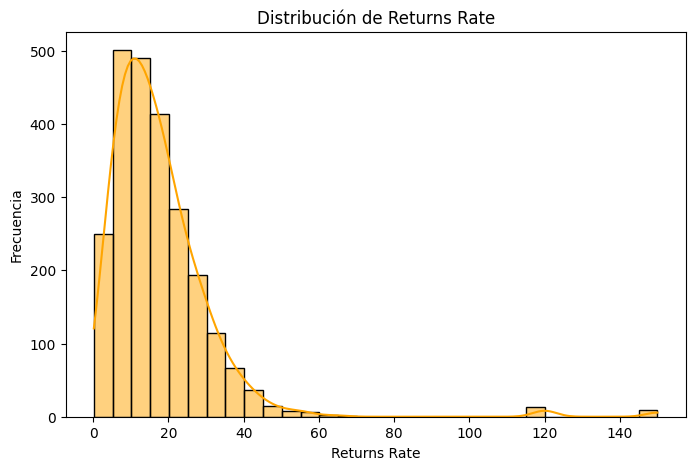

In [27]:
#Histograma de Returns_Rate
plt.figure(figsize=(8, 5))
sns.histplot(data_cleaned['Returns_Rate'], bins=30, kde=True, color='orange')
plt.title('Distribución de Returns Rate')
plt.xlabel('Returns Rate')
plt.ylabel('Frecuencia')
plt.show()

In [28]:
# ¿Cuántas de las observaciones superan el 1005 de Returns_Rate?
returns_rate_outliers = data_cleaned[data_cleaned['Returns_Rate'] > 100]
print("Número de observaciones con Returns_Rate > 100%:", len(returns_rate_outliers))

Número de observaciones con Returns_Rate > 100%: 22


In [29]:
# Eliminamos los Returns_Rate que pasen el 100%
data_cleaned = data_cleaned[data_cleaned['Returns_Rate'] <= 100]
print("Número de clientes después de eliminar Returns_Rate < 100%:", len(data_cleaned))

Número de clientes después de eliminar Returns_Rate < 100%: 2382


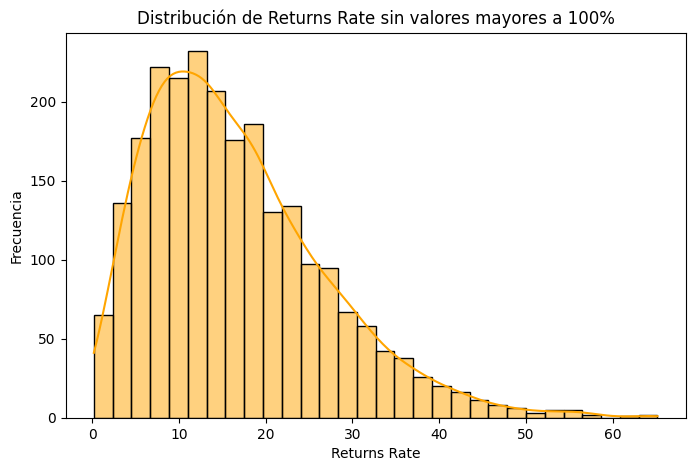

In [30]:
#Histograma de Returns_Rate sin los valores mayores a 100%
plt.figure(figsize=(8, 5))
sns.histplot(data_cleaned['Returns_Rate'], bins=30, kde=True, color='orange')
plt.title('Distribución de Returns Rate sin valores mayores a 100%')
plt.xlabel('Returns Rate')
plt.ylabel('Frecuencia')        
plt.show()

#### 11. Para la variable Satisfaction_Score, donde los missing pueden no ser aleatorios:

- 	¿Recomendarías imputar o mantener los missing como categoría?

In [31]:

# 11) Satisfaction missing no aleatorio -> indicador + imputación auxiliar
print("\nP11 Respuesta: Satisfaction_Missing + imputación con mediana para análisis numérico")
data_clean["Satisfaction_Missing"] = data_clean["Satisfaction_Score"].isna().astype(int)
sat_median = data_clean["Satisfaction_Score"].median(skipna=True)
data_clean["Satisfaction_Score_filled"] = data_clean["Satisfaction_Score"].fillna(sat_median)
print("Mediana Satisfaction =", sat_median)
print("Proporción missing Satisfaction =", data_clean["Satisfaction_Missing"].mean())


P11 Respuesta: Satisfaction_Missing + imputación con mediana para análisis numérico
Mediana Satisfaction = 7.0
Proporción missing Satisfaction = 0.05448354143019296


### Sección 2: Categoricas

#### 12. ¿Qué porcentaje de las observaciones son hombres?

In [32]:
# Tabla de frecuenbcia porcentual de la variable Gender
gender_freq = data_clean['Gender'].value_counts(normalize=True) * 100
print("\nFrecuencia porcentual de la variable Gender:")
print(gender_freq.round(2))


Frecuencia porcentual de la variable Gender:
Gender
Female    54.42
Male      45.58
Name: proportion, dtype: float64


#### 13. Analiza la variable City_Type, ¿qué % de personas son de la zona rural?

In [33]:
# Porcentaje de observaciones por la variable City_Type
city_freq = data_clean['City_Type'].value_counts(normalize=True) * 100
print("\nFrecuencia porcentual de la variable City_Type:")
print(city_freq.round(2))


Frecuencia porcentual de la variable City_Type:
City_Type
Urban       79.61
Suburban    15.55
Rural        4.84
Name: proportion, dtype: float64


#### 14. ¿El descubrimiento anterior representa algún error?,¿Cuál?
 - Sesgo de representación
 - Sesgo de medición
 - Sesgo de selección

#### 15. ¿Comó es la distribución de la variable de género en la base de datos?
- No hay sesgo de variable
- No hay sesgo de representación
- No se puede definir
- Sin comentarios

In [34]:
# Pordentaje de hombres y mujeres en la variable Gender
gender_counts = data_clean['Gender'].value_counts(normalize=True) * 100
print("\nPorcentaje de hombres y mujeres en la variable Gender:")
print(gender_counts.round(2))   


Porcentaje de hombres y mujeres en la variable Gender:
Gender
Female    54.42
Male      45.58
Name: proportion, dtype: float64


#### 16.	¿Cuáles son las tres variables más relevantes para analizar el valor del cliente para la empresa? Justifica brevemente su elección.
- Las tres variables más relevantes son:
- 1. Total_Spending: refleja el valor total gastado por el cliente, lo que directamente impacta en los ingresos de la empresa.
- 2. Avg_Ticket: indica el ticket promedio por transacción, lo que ayuda a entender la frecuencia y valor de cada compra.